In [1]:
!pip install --quiet pennylane pytorch-msssim lpips faiss-cpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/2

In [2]:
######################################################################
# 1 · Imports & helpers –––––––––––––––––––––––––––––––––––––––––––––
######################################################################
import os, json, math, random, warnings, time, itertools, numpy as np
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision.transforms as T
from torchvision.datasets.folder import default_loader
from torchvision import models

import pennylane as qml
from pennylane import numpy as pnp

from pytorch_msssim import ssim
import lpips                                   # ← perceptual metric
lpips_loss = lpips.LPIPS(net="alex").to("cuda").eval()  # **move to GPU**

from scipy.stats import genextreme as gev
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score,
                             average_precision_score)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)

SEED = 23
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# -------------------------------------------------------------------
# helper: perceptual MSE for single-channel inputs
# -------------------------------------------------------------------
def perceptual_mse(recon, x):
    """
    Compute LPIPS on grey images by replicating the single channel to RGB.
    Both inputs are assumed to be in [-1,1] and already on the *same* device.
    """
    r3 = recon.repeat(1, 3, 1, 1)
    x3 = x.repeat(1, 3, 1, 1)
    with torch.no_grad():
        return lpips_loss(r3, x3).mean()


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 223MB/s]


Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/alex.pth
Running on cuda


In [3]:
######################################################################
# 2 · Dataset loader ––––––––––––––––––––––––––––––––––––––––––––––––
######################################################################
def is_anomaly(path:str)->int:
    """MVTec convention: train/*/good are normal; others anomalous."""
    return 0 if "good" in path else 1

class MVTec(Dataset):
    def __init__(self, root:str, phase:str, tfm):
        self.samples=[]; self.transform=tfm
        self.classes = sorted([d for d in os.listdir(root)
                               if os.path.isdir(os.path.join(root,d))])
        self.cls2idx = {c:i for i,c in enumerate(self.classes)}
        for cls in self.classes:
            p = os.path.join(root, cls, phase)
            for r,_,files in os.walk(p):
                for f in files:
                    if f.endswith(".png"):
                        path=os.path.join(r,f)
                        self.samples.append((path,
                                             is_anomaly(path),
                                             self.cls2idx[cls]))
    def __len__(self): return len(self.samples)
    def __getitem__(self,idx):
        p,lbl,cid = self.samples[idx]
        return self.transform(default_loader(p)), lbl, cid, p

In [4]:
######################################################################
# 3 · Transforms, balanced loader –––––––––––––––––––––––––––––––––––
######################################################################
RES = 128                           # ↑ resolution for tiny defects
BATCH = 32

tfm_train = T.Compose([
    T.Grayscale(), T.RandomHorizontalFlip(),
    T.RandomRotation(5), T.ColorJitter(.1,.1),
    T.Resize((RES,RES)), T.ToTensor(),
    T.Normalize([.5],[.5])
])
tfm_test = T.Compose([
    T.Grayscale(), T.Resize((RES,RES)),
    T.ToTensor(),  T.Normalize([.5],[.5])
])

ROOT = "/kaggle/input/mvtec-ad"     # change if needed
train_ds = MVTec(ROOT,"train",tfm_train)
test_ds  = MVTec(ROOT,"test", tfm_test)
NUM_CL   = len(train_ds.classes)

# -------- balanced batch sampler -----------------------------------
from collections import defaultdict
class BalancedSampler(Sampler):
    def __init__(self,ds,batch):
        self.cls2idx=defaultdict(list)
        for i,(_,_,cid,_) in enumerate(ds): self.cls2idx[cid].append(i)
        self.batch=batch; self.classes=list(self.cls2idx)
        self.length=math.ceil(len(ds)/batch)
    def __iter__(self):
        ptr={c:0 for c in self.classes}
        for _ in range(self.length):
            batch=[]
            random.shuffle(self.classes)
            for c in self.classes:
                if ptr[c]<len(self.cls2idx[c]):
                    batch.append(self.cls2idx[c][ptr[c]]); ptr[c]+=1
                if len(batch)==self.batch: break
            yield batch
    def __len__(self): return self.length

train_loader = DataLoader(train_ds,
                          batch_sampler=BalancedSampler(train_ds,BATCH),
                          num_workers=4,pin_memory=True)
test_loader  = DataLoader(test_ds,batch_size=1,shuffle=False,num_workers=4)
print(f"{len(train_ds)=}, {len(test_ds)=}, {NUM_CL=}")

len(train_ds)=3629, len(test_ds)=1725, NUM_CL=15


In [5]:
######################################################################
# 4 · Quantum block (amplitude read-out) ––––––––––––––––––––––––––––
######################################################################
N_QUBITS = 6
dev = qml.device("default.qubit", wires=N_QUBITS)
AMP_DIM = 2**N_QUBITS               # 64 amplitudes

@qml.qnode(dev, interface="torch")
def q_circuit(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return qml.probs(wires=range(N_QUBITS))     # length 64

q_shape = {"weights": (3, N_QUBITS, 3)}

In [6]:
######################################################################
# 5 · VAE-Q with skip-connections –––––––––––––––––––––––––––––––––––
######################################################################
LATENT=32; EMB_DIM=32

class VAE_Q(nn.Module):
    def __init__(self):
        super().__init__()
        # ----- Encoder blocks -----
        self.enc1 = nn.Sequential(nn.Conv2d(1,32,4,2,1), nn.ReLU())   #128→64
        self.enc2 = nn.Sequential(nn.Conv2d(32,64,4,2,1), nn.ReLU())  #64→32
        self.enc3 = nn.Sequential(nn.Conv2d(64,128,4,2,1), nn.ReLU()) #32→16
        self.enc4 = nn.Sequential(nn.Conv2d(128,256,4,2,1), nn.ReLU())#16→8
        self.enc5 = nn.Sequential(nn.Conv2d(256,512,4,2,1), nn.ReLU())#8→4

        self.flatten_sz = 512*4*4
        self.mu     = nn.Linear(self.flatten_sz, LATENT)
        self.logvar = nn.Linear(self.flatten_sz, LATENT)

        # ----- class emb & quantum bottleneck -----
        self.class_emb = nn.Embedding(NUM_CL, EMB_DIM)
        self.pre_fc = nn.Sequential(nn.Linear(LATENT+EMB_DIM,16),
                                    nn.ReLU(),
                                    nn.Linear(16, N_QUBITS))

        self.q_layer = qml.qnn.TorchLayer(q_circuit, q_shape)  #64-D

        # ----- Decoder head -----
        self.dec0 = nn.Sequential(nn.Linear(AMP_DIM, 512*4*4),
                                  nn.ReLU())

        # transpose convs + skip concat
        self.up5 = nn.Sequential(nn.ConvTranspose2d(512,256,4,2,1),
                                 nn.ReLU())       # 4→8
        self.up4 = nn.Sequential(nn.ConvTranspose2d(512,128,4,2,1),
                                 nn.ReLU())       # 8→16
        self.up3 = nn.Sequential(nn.ConvTranspose2d(256,64,4,2,1),
                                 nn.ReLU())       #16→32
        self.up2 = nn.Sequential(nn.ConvTranspose2d(128,32,4,2,1),
                                 nn.ReLU())       #32→64
        self.up1 = nn.Sequential(nn.ConvTranspose2d(64,1,4,2,1),
                                 nn.Tanh())       #64→128

    # ---- plumbing ----
    def encode(self,x):
        f1=self.enc1(x); f2=self.enc2(f1); f3=self.enc3(f2)
        f4=self.enc4(f3); f5=self.enc5(f4)
        flat=f5.view(x.size(0),-1)
        return self.mu(flat), self.logvar(flat), (f1,f2,f3,f4)
    def reparam(self,mu,logvar):
        std=torch.exp(0.5*logvar)
        return mu+torch.randn_like(std)*std
    def decode(self,z,cid,feats):
        x=torch.cat([z,self.class_emb(cid)],1)
        x=self.pre_fc(x)
        x=self.q_layer(x)              # (B,64)
        x=self.dec0(x).view(-1,512,4,4)
        x=self.up5(x)                  # 8×8
        x=self.up4(torch.cat([x,feats[3]],1)) # 16×16
        x=self.up3(torch.cat([x,feats[2]],1)) # 32×32
        x=self.up2(torch.cat([x,feats[1]],1)) # 64×64
        x=self.up1(torch.cat([x,feats[0]],1)) # 128×128
        return x
    def forward(self,x,cid):
        mu,logvar,feats=self.encode(x)
        z=self.reparam(mu,logvar)
        recon=self.decode(z,cid,feats)
        return recon,mu,logvar

In [7]:

######################################################################
# 6 · Loss, optimiser, sched ––––––––––––––––––––––––––––––––––––––––
######################################################################
def beta_schedule(epoch,cycle=4,maxb=1.0):
    pos=(epoch%cycle)/cycle
    return maxb*(1-math.cos(pos*math.pi))/2

def perceptual_mse(r,x):
    with torch.no_grad():
        p=lpips_loss(r,x).mean()
    return p

def vae_loss(recon,x,mu,logvar,epoch):
    mse=F.mse_loss(recon,x,reduction="mean")
    ssim_=1-ssim(recon,x,data_range=2,size_average=True)
    lpips_=perceptual_mse(recon,x)
    recon_l=0.2*mse+0.4*ssim_+0.4*lpips_
    kld=-0.5*torch.mean(1+logvar-mu.pow(2)-logvar.exp())
    beta=beta_schedule(epoch)
    return recon_l+beta*kld, recon_l, kld

model=VAE_Q().to(device)
opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=25, eta_min=1e-5)
scaler=torch.cuda.amp.GradScaler()


In [8]:
######################################################################
# 7 · Optional PatchCore hybrid score –––––––––––––––––––––––––––––––
######################################################################
USE_PATCHCORE=False    # set True to blend feature-NN scores

if USE_PATCHCORE:
    backbone=models.resnet18(weights='IMAGENET1K_V1').to(device).eval()
    tgt_layer=backbone.layer4      # 512×8×8 on 128×128 inputs
    feats_train=[]
    def hook(_,__,out): feats_train.append(out.detach())
    tgt_layer.register_forward_hook(hook)

    with torch.no_grad():
        for x,_,_,_ in train_loader:
            backbone(x.to(device))
    F=torch.cat(feats_train,0)                         #(N,512,8,8)
    patches=F.permute(0,2,3,1).reshape(-1,512).cpu().numpy()

    import faiss, numpy as nmp
    faiss.normalize_L2(patches)
    index=faiss.IndexFlatIP(512); index.add(patches)
    print("PatchCore DB:",patches.shape)


In [9]:
######################################################################
# 8 · Training loop –––––––––––––––––––––––––––––––––––––––––––––––––
######################################################################
EPOCHS=25; history={"loss":[], "recon":[], "kld":[], "acc":[]}
best_auc=0; patience=7; bad=0

def batch_score(x,recon):
    return torch.mean((x-recon)**2,dim=[1,2,3])

for epoch in range(1,EPOCHS+1):
    t0=time.time()
    model.train(); l_tot=r_tot=k_tot=0.0
    for x,_,cid,_ in train_loader:
        x,cid=x.to(device),cid.to(device)
        with torch.cuda.amp.autocast():
            recon,mu,logvar=model(x,cid)
            loss,recon_l,kld_l=vae_loss(recon,x,mu,logvar,epoch)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad()
        bs=x.size(0)
        l_tot+=loss.item()*bs; r_tot+=recon_l.item()*bs; k_tot+=kld_l.item()*bs
    sch.step()
    N=len(train_loader.dataset)
    history["loss"].append(l_tot/N); history["recon"].append(r_tot/N); history["kld"].append(k_tot/N)

    # ---------- quick AUROC on test each epoch ----------------------
    model.eval(); y_true=[]; y_score=[]
    with torch.no_grad():
        for x,lbl,cid,_ in test_loader:
            x,cid=x.to(device),cid.to(device)
            recon,_,_=model(x,cid)
            s=batch_score(x,recon).item()
            if USE_PATCHCORE:
                f=backbone(x).permute(0,2,3,1).reshape(-1,512).cpu().numpy()
                faiss.normalize_L2(f)
                D,_=index.search(f,1)
                s=0.5*s+0.5*D.mean()
            y_true.append(lbl); y_score.append(s)
    auc=roc_auc_score(y_true,y_score)
    history["acc"].append(auc)     # store AUROC for early stop
    dt=time.time()-t0
    print(f"Ep {epoch:02d}/{EPOCHS} | loss {l_tot/N:.3f} | AUROC {auc:.3f} | {dt:.1f}s")

    if auc>best_auc: best_auc=auc; bad=0
    else:
        bad+=1
        if bad>=patience:
            print("Early stop.")
            break


Ep 01/25 | loss 0.071 | AUROC 0.616 | 93.6s
Ep 02/25 | loss 0.013 | AUROC 0.607 | 89.5s
Ep 03/25 | loss 0.008 | AUROC 0.572 | 89.1s
Ep 04/25 | loss 0.005 | AUROC 0.556 | 89.3s
Ep 05/25 | loss 0.004 | AUROC 0.547 | 90.3s
Ep 06/25 | loss 0.003 | AUROC 0.511 | 89.8s
Ep 07/25 | loss 0.003 | AUROC 0.489 | 90.4s
Ep 08/25 | loss 0.002 | AUROC 0.494 | 88.8s
Early stop.


In [10]:

######################################################################
# 9 · Final threshold via GEV tails –––––––––––––––––––––––––––––––––
######################################################################
model.eval()
cls_scores_norm=defaultdict(list); cls_scores_anom=defaultdict(list)
all_scores=[]; all_lbls=[]; all_cls=[]
with torch.no_grad():
    for x,lbl,cid,_ in test_loader:
        x,cid=x.to(device),cid.to(device)
        recon,_,_=model(x,cid)
        s=batch_score(x,recon).item()
        if USE_PATCHCORE:
            f=backbone(x).permute(0,2,3,1).reshape(-1,512).cpu().numpy()
            faiss.normalize_L2(f)
            D,_=index.search(f,1)
            s=0.5*s+0.5*D.mean()
        if lbl==0: cls_scores_norm[cid.item()].append(s)
        else:      cls_scores_anom[cid.item()].append(s)
        all_scores.append(s); all_lbls.append(lbl); all_cls.append(cid)

def gev_thr(norm,anom,min_q=0.995):
    tail=np.sort(norm)[int(0.8*len(norm)):]
    ξ,μ,σ=gev.fit(tail)
    return gev.ppf(min_q,ξ,μ,σ)
THRESH={}
for c in range(NUM_CL):
    THRESH[c]=gev_thr(cls_scores_norm[c], cls_scores_anom[c])

              precision    recall  f1-score   support

      Normal       0.28      0.99      0.44       467
     Anomaly       0.94      0.06      0.12      1258

    accuracy                           0.31      1725
   macro avg       0.61      0.53      0.28      1725
weighted avg       0.76      0.31      0.20      1725



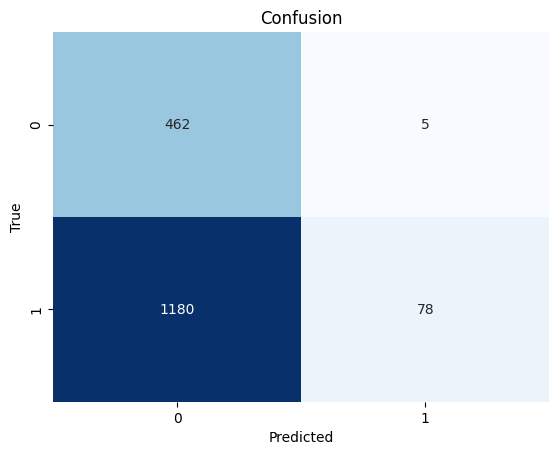

Final image-level AUROC 0.494 | AP 0.746


In [11]:
######################################################################
# 10 · Metrics & confusion ––––––––––––––––––––––––––––––––––––––––––
######################################################################
y_pred = []
with torch.no_grad():
    for s, lbl, cid in zip(all_scores, all_lbls, all_cls):
        c_int = int(cid)              # <- ensure plain int key
        y_pred.append(1 if s > THRESH[c_int] else 0)

print(classification_report(
    all_lbls, y_pred, target_names=["Normal", "Anomaly"])
)

cm = confusion_matrix(all_lbls, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion"); plt.show()

auc = roc_auc_score(all_lbls, all_scores)
ap  = average_precision_score(all_lbls, all_scores)
print(f"Final image-level AUROC {auc:.3f} | AP {ap:.3f}")


In [12]:
######################################################################
# 11 · Inspect helper –––––––––––––––––––––––––––––––––––––––––––––––
######################################################################
from pathlib import Path
def first_anomaly(ds,kw=None):
    for p,lbl,_,path in ds.samples:
        if lbl==1 and (kw is None or any(k in path for k in kw)):
            return path
def inspect(path):
    img=default_loader(path)
    x=tfm_test(img).unsqueeze(0).to(device)
    cid_name=[c for c in train_ds.classes if c in path][0]
    cid=torch.tensor([train_ds.cls2idx[cid_name]]).to(device)
    with torch.no_grad():
        recon,_,_=model(x,cid)
    score=batch_score(x,recon).item()
    if USE_PATCHCORE:
        f=backbone(x).permute(0,2,3,1).reshape(-1,512).cpu().numpy()
        faiss.normalize_L2(f); D,_=index.search(f,1); score=0.5*score+0.5*D.mean()
    pred="Anomaly 🚨" if score>THRESH[cid.item()] else "Normal ✅"
    orig=((x.squeeze().cpu().numpy()*0.5)+0.5)
    rec=((recon.squeeze().cpu().numpy()*0.5)+0.5)
    amap=np.abs(orig-rec)
    plt.figure(figsize=(10,3))
    for i,(im,t) in enumerate(zip([orig,rec,amap],
                                  ["Original","Reconstruction","Anomaly Map"])):
        plt.subplot(1,3,i+1);plt.imshow(im,cmap="gray" if i<2 else "hot")
        plt.axis("off");plt.title(t)
    plt.suptitle(f"{pred} | s={score:.4f} | thr={THRESH[cid.item()]:.4f}")
    plt.show()

In [13]:
# example usage:
#inspect(first_anomaly(test_ds, kw=["crack"]))

######################################################################
# 12 · Save artefacts –––––––––––––––––––––––––––––––––––––––––––––––
######################################################################
torch.save(model.state_dict(),"vae_q_refined.pth")
np.save("thresholds.npy",THRESH)
with open("class_to_idx.json","w") as f: json.dump(train_ds.cls2idx,f)
print("Model & thresholds saved.")

Model & thresholds saved.
